# Customer Region Analysis

## 목적

최근 완전 12개월의 고객 지역별 Item Sales,
Buyer Count와 구매 강도를 비교하고,

2017년 11월 Item Sales 증가와
2017년 12월 감소에 어떤 고객 지역의
판매금액 변화가 크게 나타났는지 분석한다.

## Region Definition

Customer Region = customers.customer_state

customer_state는 주문과 연결된 고객 주소의
브라질 주(State)를 의미한다.

## 핵심 지표

- Item Sales
- Item Sales Share
- Order Count
- Buyer Count
- Average Item Sales per Order
- Orders per Buyer
- Item Sales per Buyer

In [1]:
# 라이브러리
from pathlib import Path

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Path / DB 연결
project_root = Path.cwd().parent

database_path = (
    project_root
    / "data"
    / "processed"
    / "olist.db"
)

report_dir = (
    project_root
    / "reports"
)

figure_dir = (
    report_dir
    / "figures"
)

connection = sqlite3.connect(
    database_path
)

In [3]:
# 지역별 성과 불러오기
customer_region_df = pd.read_sql_query(
    """
    SELECT
        customer_state,

        sum(
            item_sales
        ) AS item_sales,

        count(*) AS order_count,

        count(
            DISTINCT customer_unique_id
        ) AS buyer_count,

        sum(
            item_sales
        ) * 1.0
        / count(*) AS average_item_sales_per_order,

        count(*) * 1.0
        / count(
            DISTINCT customer_unique_id
        ) AS orders_per_buyer,

        sum(
            item_sales
        ) * 1.0
        / count(
            DISTINCT customer_unique_id
        ) AS item_sales_per_buyer

    FROM analysis_orders

    GROUP BY
        customer_state

    ORDER BY
        item_sales DESC
    """,
    connection
)

print(
    customer_region_df
)

   customer_state  item_sales  order_count  buyer_count  \
0              SP  3976325.47        31828        30937   
1              RJ  1323526.69         9345         9077   
2              MG  1216237.56         8705         8480   
3              RS   549133.96         3941         3846   
4              PR   505791.09         3710         3626   
5              SC   390198.21         2691         2638   
6              BA   369483.45         2482         2416   
7              DF   233355.28         1665         1621   
8              GO   214307.13         1501         1460   
9              ES   209696.25         1516         1479   
10             PE   199593.57         1229         1202   
11             CE   164987.69          952          938   
12             PA   119969.07          673          660   
13             MT   114101.57          682          662   
14             MA    92666.17          528          516   
15             PB    87774.96          386          377 

In [4]:
# 전체 Item Sales 비중 계산
total_item_sales = (
    customer_region_df["item_sales"]
    .sum()
)

customer_region_df[
    "item_sales_share"
] = (
    customer_region_df["item_sales"]
    / total_item_sales
)

# 상위 10개
print(
    customer_region_df[
        [
            "customer_state",
            "item_sales",
            "item_sales_share",
            "buyer_count",
            "item_sales_per_buyer",
            "orders_per_buyer"
        ]
    ]
    .head(10)
)


  customer_state  item_sales  item_sales_share  buyer_count  \
0             SP  3976325.47          0.390311        30937   
1             RJ  1323526.69          0.129916         9077   
2             MG  1216237.56          0.119384         8480   
3             RS   549133.96          0.053902         3846   
4             PR   505791.09          0.049648         3626   
5             SC   390198.21          0.038301         2638   
6             BA   369483.45          0.036268         2416   
7             DF   233355.28          0.022906         1621   
8             GO   214307.13          0.021036         1460   
9             ES   209696.25          0.020584         1479   

   item_sales_per_buyer  orders_per_buyer  
0            128.529769          1.028800  
1            145.811027          1.029525  
2            143.424241          1.026533  
3            142.780541          1.024701  
4            139.490097          1.023166  
5            147.914409          1.020091 

In [5]:
# Top 지역 집중도
top_1_share = (
    customer_region_df["item_sales_share"]
    .head(1)
    .sum()
)

top_5_share = (
    customer_region_df["item_sales_share"]
    .head(5)
    .sum()
)

print(
    "Top 1 Share:",
    round(top_1_share, 4)
)

print(
    "Top 5 Share:",
    round(top_5_share,4)
)

Top 1 Share: 0.3903
Top 5 Share: 0.7432


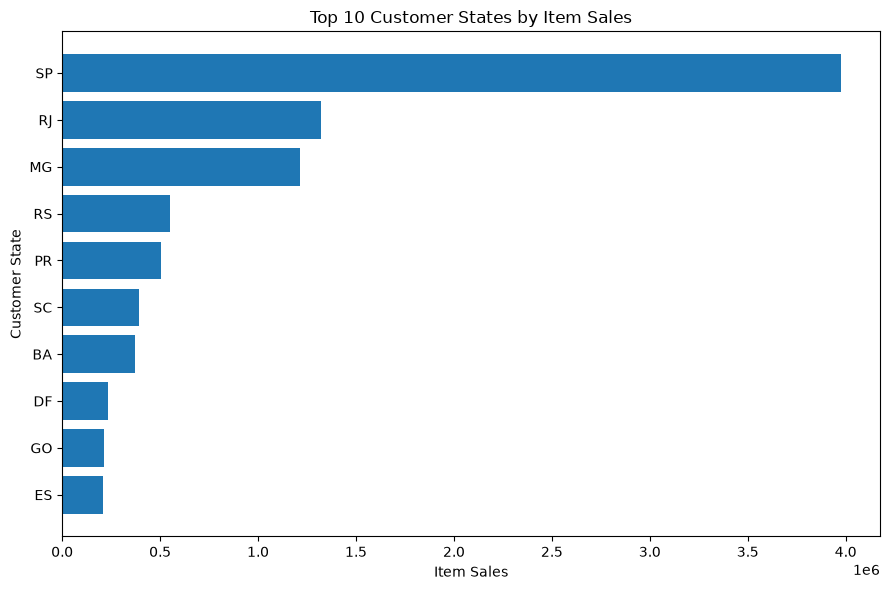

In [6]:
# 상위 지역 그래프
top_region_df = (
    customer_region_df
    .head(10)
    .sort_values(
        "item_sales"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_region_df["customer_state"],
    top_region_df["item_sales"]
)

plt.title(
    "Top 10 Customer States by Item Sales"
)

plt.xlabel(
    "Item Sales"
)

plt.ylabel(
    "Customer State"
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "top_customer_state_item_sales.png",
    dpi=150
)

plt.show()

In [7]:
# 11월 지역 변화 DataFrame
november_region_change_df = pd.read_sql_query(
    """
    SELECT
        customer_state,

        sum(
            CASE
                WHEN order_month = '2017-10'
                THEN item_sales
                ELSE 0
            END
        ) AS october_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_sales
                ELSE 0
            END
        ) AS november_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_sales
                ELSE 0
            END
        )
        -
        sum(
            CASE
                WHEN order_month = '2017-10'
                THEN item_sales
                ELSE 0
            END
        ) AS item_sales_change

    FROM analysis_orders

    WHERE
        order_month IN (
            '2017-10',
            '2017-11'
        )

    GROUP BY
        customer_state

    ORDER BY
        item_sales_change DESC
    """,
    connection
)

print(
    november_region_change_df
)

   customer_state  october_item_sales  november_item_sales  item_sales_change
0              SP           219804.08            350790.18          130986.10
1              RJ            95492.24            147782.40           52290.16
2              MG            80710.11            132686.09           51975.98
3              RS            37126.33             57463.27           20336.94
4              SC            21022.55             37870.90           16848.35
5              DF            12634.50             26406.16           13771.66
6              ES            10380.69             23858.76           13478.07
7              PR            32639.41             45751.34           13111.93
8              CE            12053.02             18353.59            6300.57
9              BA            23319.92             28819.04            5499.12
10             PA             6722.58             11666.53            4943.95
11             RO             1609.97              5852.16      

In [8]:
# 12월 지역 변화 DataFrame
december_region_change_df = pd.read_sql_query(
    """
    SELECT
        customer_state,

        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_sales
                ELSE 0
            END
        ) AS november_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-12'
                THEN item_sales
                ELSE 0
            END
        ) AS december_item_sales,

        sum(
            CASE
                WHEN order_month = '2017-12'
                THEN item_sales
                ELSE 0
            END
        )
        -
        sum(
            CASE
                WHEN order_month = '2017-11'
                THEN item_sales
                ELSE 0
            END
        ) AS item_sales_change

    FROM analysis_orders

    WHERE
        order_month IN (
            '2017-11',
            '2017-12'
        )

    GROUP BY
        customer_state

    ORDER BY
        item_sales_change
    """,
    connection
)

print(
    december_region_change_df
)

   customer_state  november_item_sales  december_item_sales  item_sales_change
0              SP            350790.18            274951.74          -75838.44
1              MG            132686.09             91152.90          -41533.19
2              RJ            147782.40            112259.63          -35522.77
3              PR             45751.34             29894.54          -15856.80
4              RS             57463.27             41904.95          -15558.32
5              SC             37870.90             24234.89          -13636.01
6              ES             23858.76             12189.76          -11669.00
7              DF             26406.16             16829.68           -9576.48
8              CE             18353.59             10299.44           -8054.15
9              GO             20726.21             15674.93           -5051.28
10             RN              8215.66              3168.45           -5047.21
11             MA              9838.59              

In [9]:
# 검산
## 11월
november_total_change = (
    november_region_change_df[
        "item_sales_change"
    ]
    .sum()
)

print(
    november_total_change
)

## 12월
december_total_change = (
    december_region_change_df[
        "item_sales_change"
    ]
    .sum()
)

print(
    december_total_change
)

339517.72000000003
-261732.17999999996


In [10]:
# 지역별 변화 기여도
## 11월
november_region_change_df[
    "change_contribution"
] = (
    november_region_change_df[
        "item_sales_change"
    ]
    / november_total_change
)

print(
    november_region_change_df.head(5)
)

## 12월
december_region_change_df[
    "change_contribution"
] = (
    december_region_change_df[
        "item_sales_change"
    ]
    / december_total_change
)

print(
    december_region_change_df.head(5)
)

  customer_state  october_item_sales  november_item_sales  item_sales_change  \
0             SP           219804.08            350790.18          130986.10   
1             RJ            95492.24            147782.40           52290.16   
2             MG            80710.11            132686.09           51975.98   
3             RS            37126.33             57463.27           20336.94   
4             SC            21022.55             37870.90           16848.35   

   change_contribution  
0             0.385800  
1             0.154013  
2             0.153088  
3             0.059899  
4             0.049624  
  customer_state  november_item_sales  december_item_sales  item_sales_change  \
0             SP            350790.18            274951.74          -75838.44   
1             MG            132686.09             91152.90          -41533.19   
2             RJ            147782.40            112259.63          -35522.77   
3             PR             45751.34        

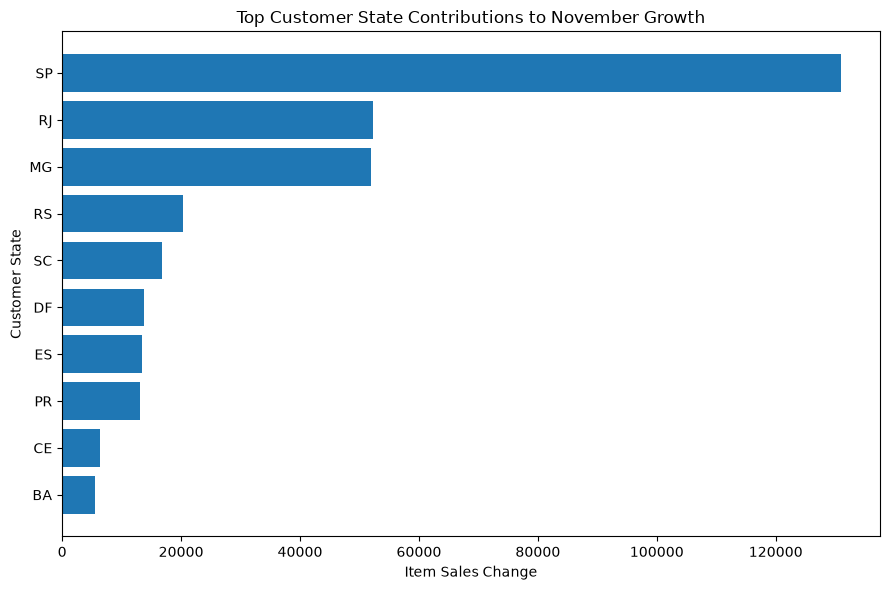

In [11]:
# 11월 상위 변화 그래프
november_top_region_df = (
    november_region_change_df
    .head(10)
    .sort_values(
        "item_sales_change"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    november_top_region_df["customer_state"],
    november_top_region_df["item_sales_change"]
)

plt.title(
    "Top Customer State Contributions to November Growth"
)

plt.xlabel(
    "Item Sales Change"
)

plt.ylabel(
    "Customer State"
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "november_region_sales_change.png",
    dpi=150
)

plt.show()

In [12]:
# CSV 저장
customer_region_df.to_csv(
    report_dir
    / "customer_region_performance.csv",
    index=False
)

november_region_change_df.to_csv(
    report_dir
    / "november_region_change.csv",
    index=False
)

december_region_change_df.to_csv(
    report_dir
    / "december_region_change.csv",
    index=False
)

# 연결 해제
connection.close()

## Analysis Results

### 전체 지역 성과

- Item Sales 1위 지역: SP
- Item Sales 2위 지역: RJ
- Item Sales 3위 지역: MG

- Top 1 지역 Item Sales 비중: 39.03%
- Top 5 지역 Item Sales 비중: 74.32%

### 고객 규모와 구매 강도

Item Sales 상위 지역은: SP

- Buyer Count: 30937
- Item Sales per Buyer: 128.53
- Orders per Buyer: 1.03

측면에서 다음과 같은 특징이 나타났다.

해석: Buyer Count 높음 / Item Sales per Buyer 중간 / Order per Buyer 중간

- 고객 기반 규모가 큰 지역

### 2017년 11월 증가

전체 Item Sales 변화:

+339,517.72

가장 큰 증가폭을 보인 지역:

1. SP
2. RJ
3. MG

해석:

2017년 11월 Item Sales 증가에서는
SP 지역의 판매금액 증가폭이 크게 나타났다.

고객 생애주기 분석에서 신규 고객 Item Sales 증가가
전체 증가의 대부분과 함께 나타났다는 점을 고려하면,
11월 성장은 신규 구매고객 확대와
주요 지역의 판매 확대가 동시에 나타난 시기로 볼 수 있다.

### 2017년 12월 감소

전체 Item Sales 변화:

-261,732.18

가장 큰 감소폭을 보인 지역:

1. SP
2. MG
3. RJ

해석:

2017년 12월 Item Sales 감소에서는
SP 지역의 판매금액 감소폭이 크게 나타났다.

Day 44에서는 기존 고객 Item Sales가 소폭 증가한 반면
신규 고객 Item Sales가 크게 감소했으므로,
12월 감소는 신규 구매고객 규모 축소와
주요 지역의 판매 감소가 함께 나타난 것으로 해석할 수 있다.

### 분석 한계

customer_state는 고객 주문 정보에 연결된 주(State)를 의미한다.

지역별 Item Sales 차이는 고객 수, 상품 구성,
가격대 및 기타 관찰되지 않은 요인의 영향을 받을 수 있다.

지역별 성과 차이만으로 마케팅이나 운영 활동의
인과 효과를 판단할 수 없다.